In [63]:
import re
import random
import numpy as np
import cv2
import torch
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from ultralytics import YOLO
from load_dataset import (
    load_video_split_file, load_frame_split_file,
    SPLIT_DIR, SPLIT_FRAMES_DIR, FACES_DIR, DATA_DIR
)

ORIG_FRAMES_DIR = DATA_DIR / 'Frames'

# Device selection: CUDA > MPS > CPU
if torch.cuda.is_available():
    DEVICE = 'cuda'
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'

print('DATA_DIR       :', DATA_DIR)
print('ORIG_FRAMES_DIR:', ORIG_FRAMES_DIR, '| exists:', ORIG_FRAMES_DIR.exists())
print('Device         :', DEVICE)

DATA_DIR       : data
ORIG_FRAMES_DIR: data/Frames | exists: True
Device         : mps


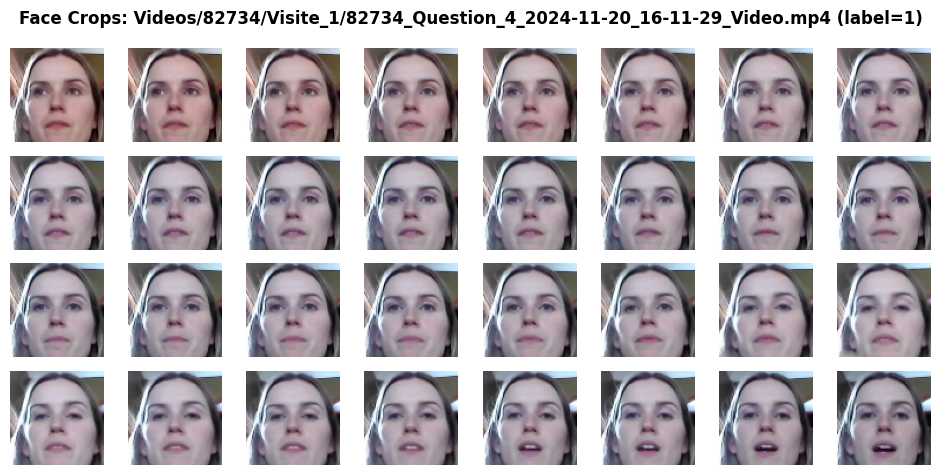

In [64]:
def show_frame_grid(frame_paths, title='Sample Frames', cols=8, thumb_size=(80, 80)):
    rows = (len(frame_paths) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.2, rows * 1.2))
    axes = np.array(axes).reshape(rows, cols)
    for i, ax in enumerate(axes.flat):
        if i < len(frame_paths):
            img = cv2.imread(str(frame_paths[i]))
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, thumb_size)
                ax.imshow(img)
        ax.axis('off')
    plt.suptitle(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

train_df = load_video_split_file(SPLIT_DIR / 'train.txt')
val_df   = load_video_split_file(SPLIT_DIR / 'val.txt')
test_df  = load_video_split_file(SPLIT_DIR / 'test.txt')

sample_row = train_df.sample(1, random_state=42).iloc[0]
video_rel = sample_row['video_path']
face_dir = FACES_DIR / video_rel
if face_dir.exists():
    face_frames = sorted(face_dir.glob('frame-*.jpg'),
                         key=lambda p: int(re.search(r'frame-(\d+)', p.name).group(1)))
    show_frame_grid(face_frames[:32], title=f'Face Crops: {video_rel} (label={sample_row["label"]})')
else:
    print('Face dir not found:', face_dir)

In [65]:
def frame_number(p):
    m = re.search(r'frame-(\d+)', p.name)
    return int(m.group(1)) if m else 0

def load_all_frames_for_video(video_rel_path, frames_root):
    video_dir = frames_root / video_rel_path
    if not video_dir.exists():
        return []
    jpgs = sorted(video_dir.glob('frame-*.jpg'), key=frame_number)
    result = []
    for p in jpgs:
        img = cv2.imread(str(p))
        if img is not None:
            result.append((frame_number(p), cv2.cvtColor(img, cv2.COLOR_BGR2RGB)))
    return result

def run_yolo_on_frames(frames, yolo_model, conf=0.30, person_class=0):
    results_list = []
    for fnum, img in frames:
        res = yolo_model(img, conf=conf, classes=[person_class], verbose=False)[0]
        boxes = res.boxes
        masks = res.masks
        detections = []
        if boxes is not None and len(boxes) > 0:
            for i in range(len(boxes)):
                det = {
                    'conf': float(boxes.conf[i]),
                    'xyxy': boxes.xyxy[i].cpu().numpy().tolist(),
                    'mask': masks.data[i].cpu().numpy() if masks is not None else None
                }
                detections.append(det)
        results_list.append({'frame_num': fnum, 'detections': detections, 'orig_img': img})
    return results_list

def draw_yolo_overlay(img, detections):
    """Crop to each detection bbox; white-out pixels outside the person mask.
    Returns list of RGB crops (one per detection). Empty list if no detections."""
    h, w = img.shape[:2]
    crops = []
    for det in detections:
        x1, y1, x2, y2 = [int(v) for v in det['xyxy']]
        x1, y1 = max(x1, 0), max(y1, 0)
        x2, y2 = min(x2, w), min(y2, h)
        crop = img[y1:y2, x1:x2].copy()
        mask = det['mask']
        if mask is not None:
            mask_full = cv2.resize(mask.astype(np.uint8), (w, h))
            mask_crop = mask_full[y1:y2, x1:x2]
            white = np.full_like(crop, 255)
            crop = np.where(mask_crop[:, :, None] > 0, crop, white)
        crops.append(crop)
    return crops

# Load YOLO model on the best available device
yolo_model = YOLO('yolo11x-seg.pt')
yolo_model.to(DEVICE)
print(f'YOLO11x-seg loaded on {DEVICE}')

YOLO11x-seg loaded on mps


In [66]:
import tqdm

SEG_OUT_DIR = DATA_DIR / 'SegmentedFrames'
SEG_OUT_DIR.mkdir(parents=True, exist_ok=True)
print('Output dir:', SEG_OUT_DIR)

# Collect all unique video paths across all splits
all_videos_df = pd.concat([train_df, val_df, test_df], ignore_index=True)
all_video_rels = all_videos_df['video_path'].unique().tolist()

# Filter to videos that have original frames on disk
available = [
    v for v in all_video_rels
    if (ORIG_FRAMES_DIR / v).exists() and any((ORIG_FRAMES_DIR / v).glob('frame-*.jpg'))
]
print(f'Total unique videos: {len(all_video_rels)} | With frames on disk: {len(available)}')

total_crops_saved = 0
total_frames_skipped = 0
total_videos_skipped = 0

for video_rel in tqdm.tqdm(available, desc='Videos', unit='video'):
    src_dir = ORIG_FRAMES_DIR / video_rel
    out_video_dir = SEG_OUT_DIR / video_rel

    src_frames = sorted(src_dir.glob('frame-*.jpg'), key=frame_number)
    if not src_frames:
        continue

    # Skip entire video if every source frame has at least one output crop
    # (or was intentionally skipped because no person was detected — marked by
    # a sentinel file frame-N.skip)
    if out_video_dir.exists():
        done = True
        for p in src_frames:
            fnum = frame_number(p)
            has_crop = any(out_video_dir.glob(f'frame-{fnum}.jpg'))
            has_skip = (out_video_dir / f'frame-{fnum}.skip').exists()
            if not has_crop and not has_skip:
                done = False
                break
        if done:
            total_videos_skipped += 1
            continue

    out_video_dir.mkdir(parents=True, exist_ok=True)

    for p in src_frames:
        fnum = frame_number(p)

        # Skip frame if already processed
        if any(out_video_dir.glob(f'frame-{fnum}.jpg')):
            total_frames_skipped += 1
            continue
        if (out_video_dir / f'frame-{fnum}.skip').exists():
            total_frames_skipped += 1
            continue

        img_bgr = cv2.imread(str(p))
        if img_bgr is None:
            continue
        img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        res = yolo_model(img, conf=0.30, classes=[0], verbose=False)[0]
        boxes = res.boxes
        masks = res.masks
        detections = []
        if boxes is not None and len(boxes) > 0:
            for i in range(len(boxes)):
                detections.append({
                    'conf': float(boxes.conf[i]),
                    'xyxy': boxes.xyxy[i].cpu().numpy().tolist(),
                    'mask': masks.data[i].cpu().numpy() if masks is not None else None
                })

        if not detections:
            # Write sentinel so we know this frame was processed but had no person
            (out_video_dir / f'frame-{fnum}.skip').touch()
            continue

        crops = draw_yolo_overlay(img, detections)
        for pid, crop in enumerate(crops):
            out_path = out_video_dir / f'frame-{fnum}.jpg'
            cv2.imwrite(str(out_path), cv2.cvtColor(crop, cv2.COLOR_RGB2BGR))
            total_crops_saved += 1

print(f'Done.')
print(f'  Videos skipped (fully done) : {total_videos_skipped}')
print(f'  Frames skipped (already done): {total_frames_skipped}')
print(f'  Crops saved                  : {total_crops_saved}')
print(f'  Output root                  : {SEG_OUT_DIR}')

Output dir: data/SegmentedFrames
Total unique videos: 1427 | With frames on disk: 1427


Videos:   3%|▎         | 47/1427 [31:31<12:17:06, 32.05s/video]

WARNING ⚠️ NMS time limit 2.050s exceeded


Videos:   5%|▌         | 76/1427 [52:14<16:54:27, 45.05s/video]

WARNING ⚠️ NMS time limit 2.050s exceeded


...

WARNING ⚠️ NMS time limit 2.050s exceeded


Videos:  11%|█         | 150/1427 [2:02:18<65:07:54, 183.61s/video]

WARNING ⚠️ NMS time limit 2.050s exceeded


Videos:  12%|█▏        | 167/1427 [2:30:23<18:54:40, 54.03s/video]  


KeyboardInterrupt: 